### Multimodal attention GNN 

**04_attention** is a deterministic model that uses a decoder with $12 \times 2 = 24$ output dimensions. Now, we will implement a multimodal version where the decoder produces $6 \times 12 \times 2 = 144$ output dimensions, representing 6 possible future trajectories.

The model will be trained to minimize the minimum ADE across the 6 predicted trajectories.

In [1]:
from pathlib import Path
import sys
import pickle

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv

/home/danilo/Desktop/gnn_trajectory/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


#### Setup data and other stuff

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.training_utils import (
    ade_loss,
    train_and_validate,
    evaluate_model,
    plot_losses,
)

from utils.graph_utils import (
    sample_to_graph,
)

from utils.analysis_utils import (
    evaluate_by_density,
    evaluate_neighbor_without_neighbors,
    neighbor_effect_by_count,
    bin_neighbor_effect,
)


# Load the processed dataset
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_path = PROCESSED_DIR / "nuscenes_train_prediction_samples.pkl"
val_path = PROCESSED_DIR / "nuscenes_val_prediction_samples.pkl"
test_path = PROCESSED_DIR / "nuscenes_test_prediction_samples.pkl"

with open(train_path, "rb") as f:
    train_dataset = pickle.load(f)

with open(val_path, "rb") as f:
    val_dataset = pickle.load(f)

with open(test_path, "rb") as f:
    test_dataset = pickle.load(f)

Building the graph datasets required to train and evaluate the attention-based GNN

In [3]:
from tqdm import tqdm

train_graphs = [sample_to_graph(sample) for sample in tqdm(train_dataset, desc="Train graphs")]
val_graphs = [sample_to_graph(sample) for sample in tqdm(val_dataset, desc="Validation graphs")]
test_graphs = [sample_to_graph(sample) for sample in tqdm(test_dataset, desc="Test graphs")]

print("\nTrain graphs:", len(train_graphs))
print("Validation graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))

Test graphs: 100%|██████████| 7242/7242 [00:01<00:00, 3775.64it/s]


Train graphs: 25711
Validation graphs: 6685
Test graphs: 7242


Create training, val and test DataLoaders

In [4]:
BATCH_SIZE = 64 

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE,shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [12]:
class GraphNetworkAttentionMultimodal(nn.Module): 
    def __init__(self, num_modes=6):
        super().__init__()
        
        self.num_modes = num_modes  # 6 
        
        # -------------------
        # ENCODER LAYER
        # -------------------
        self.encoder = nn.Sequential(
            nn.Linear(15, 64), 
            nn.ReLU()
        )
        
        # -------------------
        # ATTENTION LAYERS
        # -------------------
        self.gat1 = GATv2Conv(
            in_channels=64, 
            out_channels=64, 
            heads=1, # Each head computes its own attention coefficients and output features, allowing the model to capture different aspects of the graph structure and node features
            concat=False, # single head output, not concatenated
            edge_dim=3  # edge = [dx, dy, distance]
        )   
        
        self.gat2 = GATv2Conv(
            in_channels=64, 
            out_channels=64, 
            heads=1, 
            concat=False, 
            edge_dim=3
        )
        
        # -------------------
        # DECODER LAYER
        # -------------------
        self.decoder = nn.Sequential(
            nn.Linear(64, 128), 
            nn.ReLU(), 
            nn.Linear(128, num_modes * 12 * 2) # 6 x 12 x 2 = 144 (6 possible future trajectories, each with 12 time steps and 2D coordinates)
        )
        
    def forward(self, batch):
        
        h = self.encoder(batch.x)  # Encode node features
        h = torch.relu(self.gat1(h, batch.edge_index, batch.edge_attr))  # First attention layer
        h = torch.relu(self.gat2(h, batch.edge_index, batch.edge_attr))  # Second attention layer
        h_target = h[batch.target_mask]  # select only the target nodes for decoding
        
        pred = self.decoder(h_target)  # Decode to predict future trajectories to have shape [num_target_nodes, num_modes * 12 * 2]
        pred = pred.view(-1, self.num_modes, 12, 2)  # Reshape to [num_target_nodes, num_modes, 12, 2]
        
        return pred
    
# forward pass test 
multimodal_model = GraphNetworkAttentionMultimodal(num_modes=6).to(device)
batch = next(iter(train_loader)).to(device)
pred = multimodal_model(batch)
target = batch.y.view(-1, 12, 2)  # Reshape target to [num_target_nodes, 12, 2]

print("Prediction shape:", pred.shape)
print("Target shape:", target.shape)

Prediction shape: torch.Size([64, 6, 12, 2])
Target shape: torch.Size([64, 12, 2])


In [21]:
# # Get the 6 trajectory for the first target node in the batch
# yhat1= pred[0] # shape: [6, 12, 2]
# print(f"K = 1: {yhat1[0]}") 
# print(f"K = 2: {yhat1[1]}") 
# print(f"K = 3: {yhat1[2]}") 
# print(f"K = 4: {yhat1[3]}") 
# print(f"K = 5: {yhat1[4]}") 

#### Implement best of K=6 ADE Loss 

Taking a ***sample $i$*** in Batch B, we can compute the ADE for each ***future timestep $t$ ($t=1,2,...,12$)*** for each ***mode $k$ ($k=1,2,...,6$)*** as: 

$$d_{i,k,t} = \sqrt{(y_{i,t,x} - \hat{y}_{i,k,t,x})^2 + (y_{i,t,y} - \hat{y}_{i,k,t,y})^2}$$

Then for we do for all **12** future timesteps of that $k$ mode and average the ADE for that mode as: 

$$\text{ADE}_{i,k} = \frac{1}{12} \sum_{t=1}^{12} d_{i,k,t}$$

So each mode $k$ in this sample $i$  for this Batch $B$ gets an **single ADE value**. Then we take the minimum ADE across all modes $k$ for that sample $i$ as:

$$L_{i} = \min_k \text{ADE}_{i,k}$$

Now, we can compute the average loss across all samples $i$ in the Batch $B$ as:

$$L_{B} = \frac{1}{|B|} \sum_{i \in B} L_{i}$$

Recall again that: 

- sample $i \in {1,\dots 64}$
- mode $k \in {1, \dots 6}$
- timesteps $t  \in {1, \dots 12 }$

if still unclear check [this document](../multimodal.pdf) 

In [13]:
def best_of_k_ade_loss(pred, target): 
    """compute the best-of-k ADE loss for multimodal trajectory prediction"""
    
    # PyG batches y as [B * 12, 2].
    # Reshape target to [B, 1, 12, 2] so it broadcasts across the 6 modes
    target = target.view(-1, 1, 12, 2)  # [B, 1, 12, 2]
    
    # [B, 6, 12, 2] - [B, 1, 12, 2] = [B, 6, 12, 2] = d 
    error_d = torch.norm(pred - target, dim=-1) # [B, 6, 12] = d (for all modes k  and timesteps t)
    
    # Mean over the 12 future timesteps 
    # [B, 6, 12] -> [B, 6] = mean_d
    ade_per_mode = error_d.mean(dim=-1)  
    
    # Keep the best mode for each sample in the batch
    best_ade_per_sample = ade_per_mode.min(dim=-1).values  # [B] = best_ade_per_sample
    
    # Average over the batch 
    return best_ade_per_sample.mean()  # scalar = best_of_k_ade_loss

#### Training the multimodal attention GNN 

Epoch 1/30 | Train ADE: 4.1191 m | Val ADE: 2.7654 m
Epoch 2/30 | Train ADE: 2.6456 m | Val ADE: 2.5664 m
Epoch 3/30 | Train ADE: 2.4338 m | Val ADE: 2.5366 m
Epoch 4/30 | Train ADE: 2.3029 m | Val ADE: 2.1211 m
Epoch 5/30 | Train ADE: 2.1200 m | Val ADE: 1.9864 m
Epoch 6/30 | Train ADE: 2.0711 m | Val ADE: 2.0646 m
Epoch 7/30 | Train ADE: 2.0320 m | Val ADE: 2.0478 m
Epoch 8/30 | Train ADE: 1.9921 m | Val ADE: 1.9262 m
Epoch 9/30 | Train ADE: 1.9887 m | Val ADE: 1.9619 m
Epoch 10/30 | Train ADE: 1.9459 m | Val ADE: 1.8679 m
Epoch 11/30 | Train ADE: 1.9486 m | Val ADE: 1.8648 m
Epoch 12/30 | Train ADE: 1.9056 m | Val ADE: 1.8601 m
Epoch 13/30 | Train ADE: 1.9020 m | Val ADE: 1.8344 m
Epoch 14/30 | Train ADE: 1.9072 m | Val ADE: 1.8545 m
Epoch 15/30 | Train ADE: 1.8877 m | Val ADE: 1.8143 m
Epoch 16/30 | Train ADE: 1.8801 m | Val ADE: 1.8623 m
Epoch 17/30 | Train ADE: 1.8638 m | Val ADE: 1.8008 m
Epoch 18/30 | Train ADE: 1.8700 m | Val ADE: 1.8998 m
Epoch 19/30 | Train ADE: 1.8725 m | V

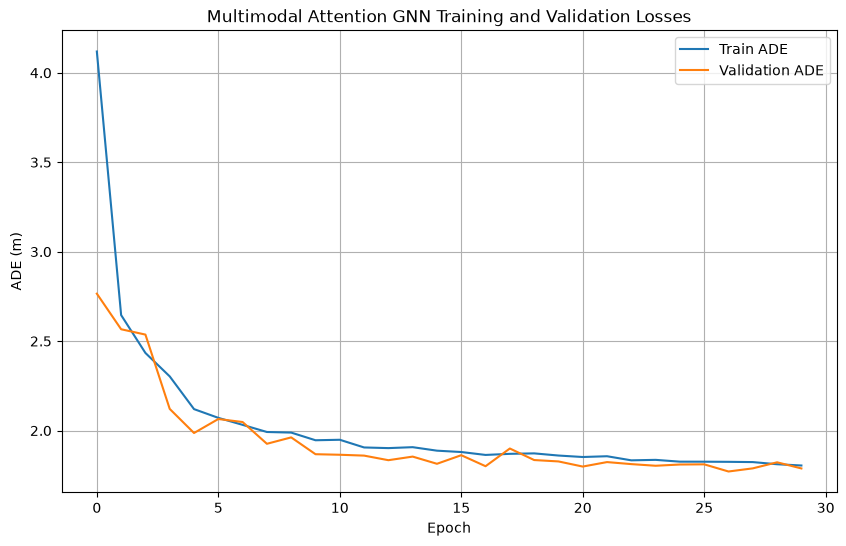

In [14]:
multimodal_model = GraphNetworkAttentionMultimodal(num_modes=6).to(device)
optimizer = torch.optim.Adam(multimodal_model.parameters(), lr=0.001)
criterion = best_of_k_ade_loss

train_losses, val_losses = train_and_validate(
    model=multimodal_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30, 
    checkpoint_path="best_multimodal_attention_model.pth",
    device=device, 
)

plot_losses(train_losses, val_losses, title="Multimodal Attention GNN Training and Validation Losses")

#### Evaluate the multimodal GNN model and compute minADE6 and minFDE metrics

In [ ]:
def evaluate_multimodal_model(model, val_loader, device=None):
    """Validation of the multimodal trajectory model using minADE6 and minFDE metrics."""
    
    if device is None: 
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    # Get the model in evaluation mode 
    model.eval()
    
    min_ades = []
    min_fdes = [] 
    
    with torch.no_grad(): # to not compute gradients 
        
        for batch in val_loader: 
            
            batch = batch.to(device)
            
            pred = model(batch) # forward pass: [B, 6, 12, 2]
            
            target = batch.y.view(-1, 12, 2)  # Reshape target to [B, 12, 2]
            
            # Compute minADE6
            # [B, 6, 12, 2]  - [B, 1, 12, 2] = [B, 6, 12, 2]
            errors_d = torch.norm(pred - target.view(-1, 1, 12, 2), dim=-1) # [B, 6, 12] = d (for all modes k and timesteps t)
            
            # Compute the mean over the 12 future timesteps to get the ADE for each mode
            ade_per_mode = errors_d.mean(dim=-1)  # [B, 6] 
            
            # Same but FDE
            fde_per_mode = errors_d[:, :, -1]  # [B, 6]
            
            # Best mode for each sample in the batch 
            best_mode_idx = ade_per_mode.argmin(dim=-1)  # [B] 
            
            batch_indices = torch.arange(batch.num_graphs,device=device)  # [B]
            
            # Get the best ADE and FDE for each sample in the batch
            best_ade_per_sample = ade_per_mode[batch_indices, best_mode_idx]  # [B]
            best_fde_per_sample = fde_per_mode[batch_indices, best_mode_idx]
            
            min_ades.extend(best_ade_per_sample.cpu().numpy())
            min_fdes.extend(best_fde_per_sample.cpu().numpy())
            
    # Average over all batches
    minADE6 = np.mean(min_ades)
    minFDE6 = np.mean(min_fdes)
    
    return minADE6, minFDE6

In [58]:
# Load best model checkpoint 
multimodal_model.load_state_dict(torch.load("best_multimodal_attention_model.pth", map_location=device))

# Validation and and compute minADE6 and minFDE metrics 
multimodal_val_ade, multimodal_val_fde = evaluate_multimodal_model(
    multimodal_model,
    val_loader,
    device
)

print(f"Validation minADE6: {multimodal_val_ade:.3f} m")
print(f"Validation minFDE6: {multimodal_val_fde:.3f} m")

Validation minADE6: 1.769 m
Validation minFDE6: 4.200 m


Plot few validation samples and compare all predicted traj with GT 